<a href="https://colab.research.google.com/github/eospgonz10/statistical_analytics_homicide/blob/main/sesiones_practicas/sp_5_juan_jose_garcia_alvarez_estiven_ospina_gonzalez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/imgs/banner_fcd.jpg?raw=1" alt="bannersp" width="1100"  height="150">

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 5: Imputación de datos</strong></span>
---
### Juan José García Álvarez
### Estiven Ospina González

## <span style="color:#2F749F;"><strong>Ejercicio 1. Limpieza e imputación de un conjunto de datos mixto</strong></span>

1. Crea el DataFrame base **df** ejecutando el siguiente código:
    ```python
    df = pd.DataFrame({
        'Nombre': ['Ana', 'Luis', 'Pedro', None, 'Marta', 'Luis', 'Sofía'],
        'Edad': [25, np.nan, 35, 29, -5, 25, None],
        'Ciudad': ['Bogotá', 'Medellín', None, 'Medellín', 'Cali', 'Bogotá', 'Cali'],
        'Ingreso': [3500, 4800, np.nan, 5200, 5100, np.nan, 4700],
        'FechaIngreso': ['2023-01-01', '2023-01-05', None, '2023-01-10', '2023-01-12', None, '2023-01-15']
    })

2. En un nuevo notebook, aplica las etapas del proceso de limpieza e imputación de datos que consideres necesarias sobre el DataFrame df. Ten encuenta incluir:
    - Código correctamente comentado y ejecutado.
    - Explicaciones breves de cada paso.
    - Resultados visuales o estadísticos que evidencien las transformaciones.

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime

df = pd.DataFrame({
        'Nombre': ['Ana', 'Luis', 'Pedro', None, 'Marta', 'Luis', 'Sofía'],
        'Edad': [25, np.nan, 35, 29, -5, 25, None],
        'Ciudad': ['Bogotá', 'Medellín', None, 'Medellín', 'Cali', 'Bogotá', 'Cali'],
        'Ingreso': [3500, 4800, np.nan, 5200, 5100, np.nan, 4700],
        'FechaIngreso': ['2023-01-01', '2023-01-05', None, '2023-01-10', '2023-01-12', None, '2023-01-15']
    })

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Nombre        6 non-null      object 
 1   Edad          5 non-null      float64
 2   Ciudad        6 non-null      object 
 3   Ingreso       5 non-null      float64
 4   FechaIngreso  5 non-null      object 
dtypes: float64(2), object(3)
memory usage: 412.0+ bytes


In [ ]:
# Conteo de variables nulas

df.isnull().sum()

,0
Nombre,1
Edad,2
Ciudad,1
Ingreso,2
FechaIngreso,2


In [ ]:
# Quitamos tildes

import unicodedata

def remove_accents(text):
    if isinstance(text, str):
        return ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')
    return text

df['Nombre'] = df['Nombre'].apply(remove_accents)
df['Ciudad'] = df['Ciudad'].apply(remove_accents)

In [ ]:
# Imputamos nombres nulos con 'nn'

df['Nombre'] = df['Nombre'].str.strip().str.lower()
df['Nombre'].fillna('unknown', inplace=True)

# Imputamos edades nulas con la mediana

df.loc[df['Edad'] < 0, 'Edad'] = np.nan
df['Edad'].fillna(df['Edad'].median(), inplace=True)

# Imputamos ciudades nulas con la moda

df['Ciudad'] = df['Ciudad'].str.strip().str.lower()
df['Ciudad'].fillna('unknown', inplace=True)

# Imputamos los ingresos nulos con la media

df['Ingreso'].fillna(df['Ingreso'].mean(), inplace=True)

# Imputamos las fechas nulas con el año 1900

df['FechaIngreso'] = pd.to_datetime(df['FechaIngreso'], errors='coerce')
date_string = '1900-01-01'
datetime_object = pd.to_datetime(date_string)
df['FechaIngreso'].fillna(datetime_object, inplace=True)

/tmp/ipykernel_2502/1270025408.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Nombre'].fillna('unknown', inplace=True)
/tmp/ipykernel_2502/1270025408.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [ ]:
# Conteo de variables nulas después de la imputación

df.isnull().sum()

,0
Nombre,0
Edad,0
Ciudad,0
Ingreso,0
FechaIngreso,0


In [ ]:
# DataFrame después de la imputación

df.head(7)

,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
0,ana,25.0,bogota,3500.0,2023-01-01
1,luis,27.0,medellin,4800.0,2023-01-05
2,pedro,35.0,unknown,4660.0,1900-01-01
3,unknown,29.0,medellin,5200.0,2023-01-10
4,marta,27.0,cali,5100.0,2023-01-12
5,luis,25.0,bogota,4660.0,1900-01-01
6,sofia,27.0,cali,4700.0,2023-01-15


## <span style="color:#2F749F;"><strong>Ejercicio 2. Limpieza de duplicados</strong></span>

1. Crea el DataFrame base **df** ejecutando el siguiente código:
    ```python
    df = pd.DataFrame({
        'ID': [101, 102, 102, 103, 104, 104, 104],
        'Nombre': ['Ana', 'Luis', 'Luis', 'Marta', 'Carlos', 'Carlos', 'Carlos'],
        'Edad': [25, 30, 30, 29, 40, 40, 41],
        'Ciudad': ['Bogotá', 'Cali', 'Cali', 'Medellín', 'Cali', 'Cali', 'Cali'],
        'FechaRegistro': ['2023-01-01', '2023-01-05', '2023-01-05', '2023-01-10',
                        '2023-01-15', '2023-01-15', '2023-01-16']
    })

2.  En el mismo notebook anterior, para el nuevo dataframe df, responde a las siguientes preguntas (utilizando python):
    - ¿Cuál es el total de registros originales?
    - ¿Cuáles y cuántos son los duplicados exactos?
    - ¿Cuáles y cuántos son los duplicados por varias columnas?
    - ¿Cuántos registros debes eliminar?
    - ¿Cuántos registros quedan después de la limpieza?

In [ ]:
df = pd.DataFrame({
    'ID': [101, 102, 102, 103, 104, 104, 104],
    'Nombre': ['Ana', 'Luis', 'Luis', 'Marta', 'Carlos', 'Carlos', 'Carlos'],
    'Edad': [25, 30, 30, 29, 40, 40, 41],
    'Ciudad': ['Bogotá', 'Cali', 'Cali', 'Medellín', 'Cali', 'Cali', 'Cali'],
    'FechaRegistro': ['2023-01-01', '2023-01-05', '2023-01-05', '2023-01-10',
                    '2023-01-15', '2023-01-15', '2023-01-16']
})

In [ ]:
df.head()

,ID,Nombre,Edad,Ciudad,FechaRegistro
0,101,Ana,25,Bogotá,2023-01-01
1,102,Luis,30,Cali,2023-01-05
2,102,Luis,30,Cali,2023-01-05
3,103,Marta,29,Medellín,2023-01-10
4,104,Carlos,40,Cali,2023-01-15


In [ ]:
# Total de registros

total_registros = df.shape[0]
print(f"Total de registros: {total_registros}")

Total de registros: 7


In [ ]:
# Duplicados exactos

duplicados_exactos = df[df.duplicated(keep=False)]
num_duplicados_exactos = duplicados_exactos.shape[0]

print(f"\nNúmero de duplicados exactos: {num_duplicados_exactos}")
print("Registros de duplicados exactos:\n", duplicados_exactos)


Número de duplicados exactos: 4
Registros de duplicados exactos:
     ID  Nombre  Edad Ciudad FechaRegistro
1  102    Luis    30   Cali    2023-01-05
2  102    Luis    30   Cali    2023-01-05
4  104  Carlos    40   Cali    2023-01-15
5  104  Carlos    40   Cali    2023-01-15


In [ ]:
# Total de registros originales

total_originales = total_registros - num_duplicados_exactos
print("Total de registros originales: ", total_originales)

Total de registros originales:  3


Para el punto 3, consideremos duplicados por las columnas 'ID' y 'Nombre', ya que 'Edad' y 'FechaRegistro' pueden variar aunque sean la misma persona/registro lógico.

In [ ]:
# Duplicados por columnas ID y Nombre

duplicados_por_columnas = df[df.duplicated(subset=['ID', 'Nombre'], keep=False)]
num_duplicados_por_columnas = duplicados_por_columnas.shape[0]

print(f"\nNúmero de duplicados por 'ID' y 'Nombre': {num_duplicados_por_columnas}")
print("Registros duplicados por 'ID' y 'Nombre':\n", duplicados_por_columnas)


Número de duplicados por 'ID' y 'Nombre': 5
Registros duplicados por 'ID' y 'Nombre':
     ID  Nombre  Edad Ciudad FechaRegistro
1  102    Luis    30   Cali    2023-01-05
2  102    Luis    30   Cali    2023-01-05
4  104  Carlos    40   Cali    2023-01-15
5  104  Carlos    40   Cali    2023-01-15
6  104  Carlos    41   Cali    2023-01-16


**Eliminación de registros**

Para eliminar, generalmente se elimina una de las copias, manteniendo la primera.

Los que se eliminarían son aquellos que no son la primera ocurrencia.

In [ ]:
registros_a_eliminar_exactos = df[df.duplicated(keep='first')].shape[0]

print(f"\nRegistros a eliminar si se consideran duplicados exactos: {registros_a_eliminar_exactos}")

# Si consideramos duplicados por 'ID' y 'Nombre'
registros_a_eliminar_por_columnas = df[df.duplicated(subset=['ID', 'Nombre'], keep='first')].shape[0]
print(f"Registros a eliminar si se consideran duplicados por 'ID' y 'Nombre': {registros_a_eliminar_por_columnas}")



Registros a eliminar si se consideran duplicados exactos: 2
Registros a eliminar si se consideran duplicados por 'ID' y 'Nombre': 3


In [ ]:
# Número de registros después de la limpieza

# Si se eliminan duplicados exactos
df_limpio_exactos = df.drop_duplicates(keep='first')
registros_despues_limpieza_exactos = df_limpio_exactos.shape[0]

print(f"\nRegistros después de la limpieza (duplicados exactos): {registros_despues_limpieza_exactos}")
print("DataFrame después de la limpieza (duplicados exactos):\n", df_limpio_exactos)

# Si se eliminan duplicados por 'ID' y 'Nombre'
df_limpio_por_columnas = df.drop_duplicates(subset=['ID', 'Nombre'], keep='first')
registros_despues_limpieza_por_columnas = df_limpio_por_columnas.shape[0]

print(f"\nRegistros después de la limpieza (duplicados por 'ID' y 'Nombre'): {registros_despues_limpieza_por_columnas}")
print("DataFrame después de la limpieza (duplicados por 'ID' y 'Nombre'):\n", df_limpio_por_columnas)


Registros después de la limpieza (duplicados exactos): 5
DataFrame después de la limpieza (duplicados exactos):
     ID  Nombre  Edad    Ciudad FechaRegistro
0  101     Ana    25    Bogotá    2023-01-01
1  102    Luis    30      Cali    2023-01-05
3  103   Marta    29  Medellín    2023-01-10
4  104  Carlos    40      Cali    2023-01-15
6  104  Carlos    41      Cali    2023-01-16

Registros después de la limpieza (duplicados por 'ID' y 'Nombre'): 4
DataFrame después de la limpieza (duplicados por 'ID' y 'Nombre'):
     ID  Nombre  Edad    Ciudad FechaRegistro
0  101     Ana    25    Bogotá    2023-01-01
1  102    Luis    30      Cali    2023-01-05
3  103   Marta    29  Medellín    2023-01-10
4  104  Carlos    40      Cali    2023-01-15


## <span style="color:#2F749F;"><strong>Ejercicio 3. Corrección de errores tipográficos o de codificación</strong></span>


1. Crea el DataFrame base **df** ejecutando el siguiente código:
    ```python
    df = pd.DataFrame({
        'Ciudad': ['bogota', 'Bogotá', 'BOGOTA', 'bogotá', 'bogata', 'Bógota', 'BogoTa', 'Cali', 'calí', 'medellín', 'medellin']
    })

2.  En el mismo notebook anterior, para el nuevo dataframe df, estandariza la variable ciudad utilizando python.

In [ ]:
df = pd.DataFrame({
    'Ciudad': ['bogota', 'Bogotá', 'BOGOTA', 'bogotá', 'bogata', 'Bógota', 'BogoTa', 'Cali', 'calí', 'medellín', 'medellin']
})

In [ ]:
from difflib import get_close_matches

ciudades_unicas = df['Ciudad'].unique()

for ciudad in ciudades_unicas:
    print(get_close_matches(ciudad, df['Ciudad'].unique()))

['bogota', 'bogotá', 'bogata']
['Bogotá', 'bogotá', 'bogota']
['BOGOTA']
['bogotá', 'bogota', 'Bogotá']
['bogata', 'bogota', 'bogotá']
['Bógota', 'bogota', 'Bogotá']
['BogoTa', 'bogota', 'Bógota']
['Cali']
['calí']
['medellín', 'medellin']
['medellin', 'medellín']


In [ ]:
df['Ciudad'] = df['Ciudad'].str.strip().str.lower().apply(remove_accents)

# Definimos una lista de ciudades correctas con las que comparar
ciudades_correctas = ['bogota', 'cali', 'medellin']

# Obtenemos los valores únicos (ya limpios) para iterar
ciudades_a_corregir = df['Ciudad'].unique()

# Iteramos sobre los valores únicos y aplicamos las correcciones
for ciudad_original in ciudades_a_corregir:
    matches = get_close_matches(ciudad_original, ciudades_correctas)
    if matches:
        best_match = matches[0]
        if ciudad_original != best_match: # Si la ciudad original es diferente de la mejor coincidencia
            df['Ciudad'] = df['Ciudad'].replace(ciudad_original, best_match)

print("Valores únicos de la columna 'Ciudad' después de la imputación:")
print(df['Ciudad'].unique())

Valores únicos de la columna 'Ciudad' después de la imputación:
['bogota' 'cali' 'medellin']


In [ ]:
display(df.head(11))

,Ciudad
0,bogota
1,bogota
2,bogota
3,bogota
4,bogota
5,bogota
6,bogota
7,cali
8,cali
9,medellin


## <span style="color:#2F749F;"><strong>Ejercicio 4. Identificación de mecanismos de datos faltantes (MCAR, MAR, MNAR)</strong></span>
1. Se tiene una base de datos de estudiantes universitarios con las siguientes variables: , Edad, Género, Promedio académico, Ingreso familiar y Horas de estudio por semana. Sin embargo, hay valores faltantes en algunas variables.
2. En los siguientes escenarios, clasifica el tipo de dato faltante (MCAR, MAR o MNAR) y justifica tu respuesta en máximo 2 líneas.
   - **Escenario 1.**  Al analizar los datos, se observa que los valores faltantes en Ingreso familiar aparecen de forma completamente aleatoria, sin relación con ninguna otra variable (ni edad, ni género, ni promedio, etc.).
   - **Escenario 2.** Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.
   - **Escenario 3.** Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.
   - **Escenario 4.** Se observa que los valores faltantes en Promedio académico aparecen con mayor frecuencia en estudiantes de cierto género.
   - **Escenario 5.** Algunos estudiantes con muy pocas horas de estudio no reportan esta variable porque consideran que el valor es “demasiado bajo” para registrarlo.
   

**SOLUCIÓN:**

**Escenario 1**
MCAR. Se indica que los datos faltantes aparecen de forma completamente aleatoria y no hay relación con ninguna otra variable.

**Escenario 2 y 3**
MAR. Hay valores faltantes de horas de estudio y se detecta que hay una relación con los promedios bajos.

**Escenario 4**
MAR. Hay valores faltantes en promedio académico y se detecta relación con el género de los estudiantes.

**Escenario 5**
MNAR. Hay valores faltantes en horas de estudio y se indica que el valor es "demasiado bajo" para registrarlo, por lo que depende directamente del valor faltante, y no de otra variable.

## <span style="color:#2F749F;"><strong>Ejercicio 5. Imputación con KNN y regresión</strong></span>

1. Crea el DataFrame base ejecutando el siguiente código:

    ```python
        import pandas as pd
        import numpy as np

        np.random.seed(42)

        n = 30

        df = pd.DataFrame({
            'Edad': np.random.randint(18, 60, n),
            'Promedio': np.round(np.random.uniform(2.0, 5.0, n), 2),
            'Horas_estudio': np.random.randint(0, 40, n),
            'Ingreso_familiar': np.random.randint(800000, 8000000, n),
            'Semestres_cursados': np.random.randint(1, 10, n)
        })

        # Introducción de valores faltantes con distintos patrones
        df.loc[[2, 5, 8, 15], 'Promedio'] = np.nan
        df.loc[[1, 7, 10, 18], 'Horas_estudio'] = np.nan
        df.loc[[3, 6, 14], 'Ingreso_familiar'] = np.nan

2. Al analizar el dataframe `df`:
   - ¿Qué variables tienen mayor proporción de datos faltantes?
   - ¿Observas algún patrón estructurado o parecen aleatorios?

3. Realiza la imputación de valores faltantes utilizando KNN y regresión
4. Analiza si se preserva la naturaleza de los datos con cada una de las técnicas de imputación (KNN y regresión)

In [53]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 30

df = pd.DataFrame({
    'Edad': np.random.randint(18, 60, n),
    'Promedio': np.round(np.random.uniform(2.0, 5.0, n), 2),
    'Horas_estudio': np.random.randint(0, 40, n),
    'Ingreso_familiar': np.random.randint(800000, 8000000, n),
    'Semestres_cursados': np.random.randint(1, 10, n)
})

# Introducción de valores faltantes con distintos patrones
df.loc[[2, 5, 8, 15], 'Promedio'] = np.nan
df.loc[[1, 7, 10, 18], 'Horas_estudio'] = np.nan
df.loc[[3, 6, 14], 'Ingreso_familiar'] = np.nan

In [54]:
# Variables con más datos faltantes

df.isnull().sum()

,0
Edad,0
Promedio,4
Horas_estudio,4
Ingreso_familiar,3
Semestres_cursados,0


In [55]:
df.head(30)

,Edad,Promedio,Horas_estudio,Ingreso_familiar,Semestres_cursados
0,56,2.70,35.0,2909818.0,7
1,46,2.27,NaN,3031785.0,7
2,32,NaN,30.0,5283302.0,9
3,25,3.15,14.0,NaN,3
4,38,4.95,7.0,3525928.0,7
5,56,NaN,13.0,4653339.0,1
6,36,4.58,22.0,NaN,4
7,40,4.04,NaN,1879111.0,4
8,28,NaN,20.0,1796107.0,5
9,28,2.04,15.0,4321441.0,7


No se logra observar algún patrón que pueda describir el comportamiento de los datos faltantes en este caso. Se concluye que los datos faltantes son aleatorios.

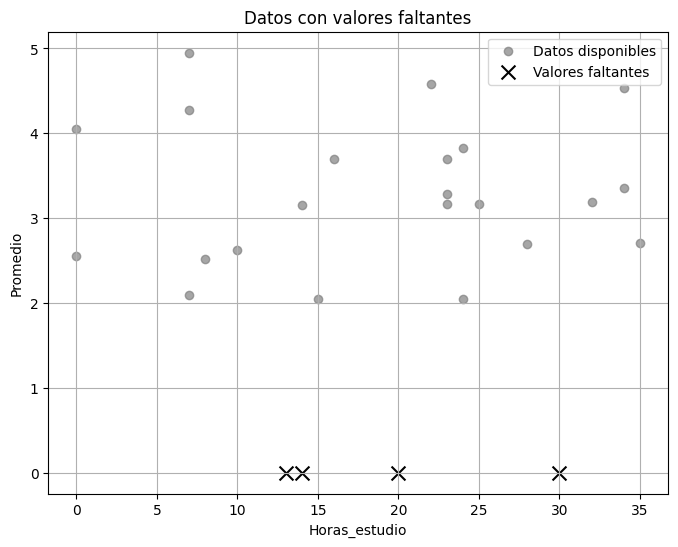

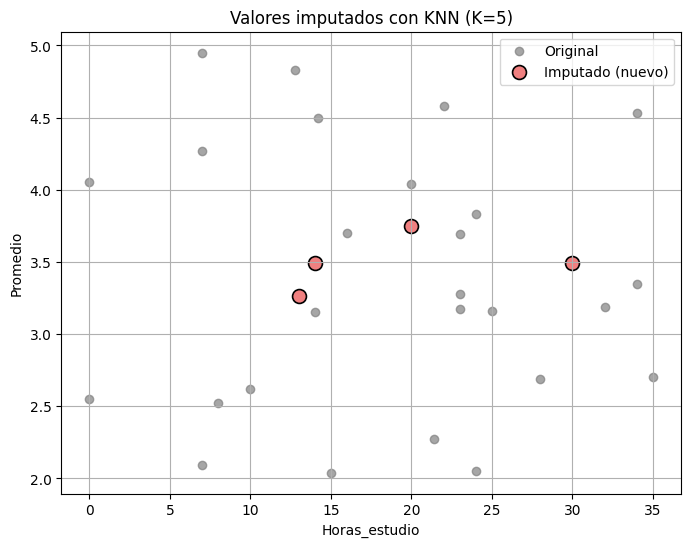

In [59]:
# Imputación con KNN
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt

data_missing = df.copy()

imputer = KNNImputer(n_neighbors=5)
imputed_df = pd.DataFrame(imputer.fit_transform(data_missing), columns=df.columns)

mask_missing = data_missing["Promedio"].isnull()

# gráfica faltantes

plt.figure(figsize=(8,6))
plt.scatter(data_missing["Horas_estudio"], data_missing["Promedio"],
            color="gray", alpha=0.7, label="Datos disponibles")
plt.scatter(imputed_df.loc[mask_missing, "Horas_estudio"],
            [0]*mask_missing.sum(),
            marker="x", color="black", s=100, label="Valores faltantes")

plt.xlabel("Horas_estudio")
plt.ylabel("Promedio")
plt.title("Datos con valores faltantes")
plt.legend()
plt.grid(True)
plt.show()

# gráfica imputados KNN

plt.figure(figsize=(8,6))
plt.scatter(imputed_df.loc[~mask_missing, "Horas_estudio"],
            imputed_df.loc[~mask_missing, "Promedio"],
            color="gray", alpha=0.7, label="Original")
plt.scatter(imputed_df.loc[mask_missing, "Horas_estudio"],
            imputed_df.loc[mask_missing, "Promedio"],
            color="lightcoral", edgecolors="black", linewidths=1.2,
            s=100, label="Imputado (nuevo)")

plt.xlabel("Horas_estudio")
plt.ylabel("Promedio")
plt.title("Valores imputados con KNN (K=5)")
plt.legend()
plt.grid(True)
plt.show()

In [58]:
imputed_df.head(30)

,Edad,Promedio,Horas_estudio,Ingreso_familiar,Semestres_cursados
0,56.0,2.700,35.0,2909818.0,7.0
1,46.0,2.270,21.4,3031785.0,7.0
2,32.0,3.492,30.0,5283302.0,9.0
3,25.0,3.150,14.0,3558188.8,3.0
4,38.0,4.950,7.0,3525928.0,7.0
5,56.0,3.260,13.0,4653339.0,1.0
6,36.0,4.580,22.0,4301436.6,4.0
7,40.0,4.040,20.0,1879111.0,4.0
8,28.0,3.746,20.0,1796107.0,5.0
9,28.0,2.040,15.0,4321441.0,7.0


In [31]:
# Conteo de nulos tras la imputación

imputed_df.isnull().sum()

,0
Edad,0
Promedio,0
Horas_estudio,0
Ingreso_familiar,0
Semestres_cursados,0


In [37]:
# Imputación con regresión

from sklearn.linear_model import LinearRegression

data_missing_reg_1 = df.copy()

# Se imputa horas de estudio con la edad
mask_missing = data_missing_reg_1["Horas_estudio"].isnull()
X_train = data_missing_reg_1.loc[~mask_missing, ["Edad"]]
y_train = data_missing_reg_1.loc[~mask_missing, "Horas_estudio"]

X_missing = data_missing_reg_1.loc[mask_missing, ["Edad"]]

reg = LinearRegression()
reg.fit(X_train, y_train)

data_imputed = data_missing_reg_1.copy()
data_imputed.loc[mask_missing, "Horas_estudio"] = reg.predict(X_missing)

In [38]:
data_imputed.head()

,Edad,Promedio,Horas_estudio,Ingreso_familiar,Semestres_cursados
0,56,2.70,35.000000,2909818.0,7
1,46,2.27,19.533681,3031785.0,7
2,32,NaN,30.000000,5283302.0,9
3,25,3.15,14.000000,NaN,3
4,38,4.95,7.000000,3525928.0,7


In [39]:
data_missing_reg_2 = data_imputed.copy()

# Se imputa promedio con horas de estudio
mask_missing = data_missing_reg_2["Promedio"].isnull()
X_train = data_missing_reg_2.loc[~mask_missing, ["Horas_estudio"]]
y_train = data_missing_reg_2.loc[~mask_missing, "Promedio"]

X_missing = data_missing_reg_2.loc[mask_missing, ["Horas_estudio"]]

reg = LinearRegression()
reg.fit(X_train, y_train)

data_imputed = data_missing_reg_2.copy()
data_imputed.loc[mask_missing, "Promedio"] = reg.predict(X_missing)

In [40]:
data_imputed.head()

,Edad,Promedio,Horas_estudio,Ingreso_familiar,Semestres_cursados
0,56,2.700000,35.000000,2909818.0,7
1,46,2.270000,19.533681,3031785.0,7
2,32,3.403519,30.000000,5283302.0,9
3,25,3.150000,14.000000,NaN,3
4,38,4.950000,7.000000,3525928.0,7


## <span style="color:#2F749F;"><strong>Ejercicio 6. Imputación con LOCF y NOCB</strong></span>

1. Crea el DataFrame base ejecutando el siguiente código:

    ```python
        import pandas as pd
        import numpy as np

        np.random.seed(42)

        n = 30

        df = pd.DataFrame({
            'Fecha': pd.date_range(start='2023-01-01', periods=n, freq='D'),
            'Ventas': np.round(np.random.uniform(100, 500, n), 2),
            'Inventario': np.random.randint(10, 100, n),
            'Clientes': np.random.randint(1, 50, n)
        })

        # Introducción de valores faltantes
        df.loc[[3, 4, 5, 12, 13], 'Ventas'] = np.nan
        df.loc[[7, 8, 20], 'Inventario'] = np.nan
        df.loc[[1, 2, 18, 19], 'Clientes'] = np.nan
        df = df.sort_values('Fecha').reset_index(drop=True)

2. Al analizar el DataFrame `df`:
   - ¿Qué variables presentan datos faltantes consecutivos?
   - ¿Por qué este tipo de patrón es relevante en series temporales?
   - ¿Qué implicaciones tiene el orden de los datos para este tipo de imputación?
3. Realiza la imputación de valores faltantes utilizando LOCF y NOCB
4. ¿Cuál método consideras más apropiado para este caso y por qué?